# Step 1 — Extract Dataset from .db3 Bag

Reads the Science Truck ROS2 bag directly as SQLite. No ROS installation needed.

**Output files (saved to `data/`):**
- `X_features.npy` — feature matrix, shape (N, 4098) — flattened 64×64 edge patch + x_norm + angle_norm
- `y_labels.npy` — integer class labels (0=LEFT, 1=STRAIGHT, 2=RIGHT)
- `y_steering.npy` — original continuous steering floats in `[-1.0, 1.0]`

## Feature pipeline (Lab07b approach on real bag frames)

$$
\text{BGR frame} \rightarrow \text{resize 320×180} \rightarrow \text{grayscale} \rightarrow \text{ROI (bottom 55\%)} \rightarrow \text{Canny edges} \rightarrow \text{Hough segments} \rightarrow \text{64×64 patch} + \text{x\_norm} + \text{angle\_norm} \rightarrow \text{flatten}
$$

The dominant Hough segment is selected by length. Its centre is used to crop a 64×64 edge patch.
Two geometric features are appended: normalised x-position of the segment centre (−1=left, +1=right)
and the segment angle normalised by 90°. Frames with no detectable segment are discarded.

## Label scheme

Labels come from real `angular.z` steering recorded in the bag (not synthetic):
- `0 = LEFT`     (steering < −0.08)
- `1 = STRAIGHT` (−0.08 ≤ steering ≤ +0.08)
- `2 = RIGHT`    (steering > +0.08)

After SVM prediction the class is mapped back to a float via the mean steering per class.

## 1. Imports and paths

In [1]:
import sqlite3
import struct
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_ROOT  = Path("D:/HSHL_resources_v2/6th_Semester/Autonomous_Systems_A/Autonomous_Systems_A_Lab_Group_4")
BAG_DIR    = REPO_ROOT / "student_lineFollowing_HSHL/bags/session_2026-05-18_12-28-17_0"
DB3_FILE   = BAG_DIR / "session_2026-05-18_13-32-59_0.db3"
DATA_DIR   = REPO_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

CLASS_NAMES = np.array(["LEFT", "STRAIGHT", "RIGHT"])
DEAD_BAND   = 0.08
RESIZE_W, RESIZE_H = 160, 90

assert DB3_FILE.exists(), f"DB3 not found — is the download complete?\n{DB3_FILE}"
print("DB3 file:", DB3_FILE)
print("Size (MB):", round(DB3_FILE.stat().st_size / 1e6, 1))

DB3 file: D:\HSHL_resources_v2\6th_Semester\Autonomous_Systems_A\Autonomous_Systems_A_Lab_Group_4\student_lineFollowing_HSHL\bags\session_2026-05-18_12-28-17_0\session_2026-05-18_13-32-59_0.db3
Size (MB): 9398.7


## 2. Inspect the SQLite database

In [2]:
con = sqlite3.connect(str(DB3_FILE))

topics_df = pd.read_sql("SELECT * FROM topics", con)
print(topics_df[["id", "name", "type"]].to_string(index=False))

# The messages table index is corrupt past rowid ~145000 (download issue).
# All queries use rowid-bounded scans to stay in the readable portion.
MAX_ROWID = 145_000

counts = con.execute(
    "SELECT topic_id, COUNT(*) as count FROM messages "
    "WHERE rowid BETWEEN 1 AND ? GROUP BY topic_id",
    (MAX_ROWID,)
).fetchall()
print()
for tid, cnt in counts:
    name = topics_df.loc[topics_df["id"] == tid, "name"].iloc[0]
    print(f"  {name}: {cnt}")

 id                                name                            type
  1                   /carla/hero/speed            std_msgs/msg/Float32
  2             /carla/hero/control_cmd         geometry_msgs/msg/Twist
  3 /carla/hero/camera/image/compressed sensor_msgs/msg/CompressedImage



  /carla/hero/speed: 48485
  /carla/hero/control_cmd: 48486
  /carla/hero/camera/image/compressed: 48029


## 3. Extract steering labels from control_cmd

CDR layout for `geometry_msgs/Twist` (all float64, little-endian):
```
offset  0 : CDR header (4 bytes)
offset  4 : linear.x   (throttle)
offset 12 : linear.y   (brake)
offset 20 : linear.z
offset 28 : angular.x
offset 36 : angular.y
offset 44 : angular.z  ← STEERING
```

Parsed: 48486 steering values
Range: [-0.820, 0.455]


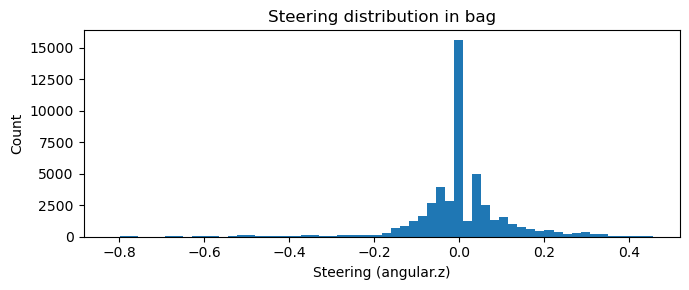

In [3]:
ctrl_id = int(topics_df.loc[topics_df["name"].str.contains("control_cmd"), "id"].iloc[0])

STEER_OFFSET = 4 + 5 * 8  # = 44
ctrl_timestamps, ctrl_steering = [], []

for ts, data in con.execute(
    "SELECT timestamp, data FROM messages "
    "WHERE topic_id = ? AND rowid BETWEEN 1 AND ?",
    (ctrl_id, MAX_ROWID)
):
    try:
        steer = struct.unpack_from('<d', data, STEER_OFFSET)[0]
        ctrl_timestamps.append(ts)
        ctrl_steering.append(steer)
    except struct.error:
        pass

ctrl_timestamps = np.array(ctrl_timestamps, dtype=np.int64)
ctrl_steering   = np.array(ctrl_steering,   dtype=np.float64)

print(f"Parsed: {len(ctrl_steering)} steering values")
print(f"Range: [{ctrl_steering.min():.3f}, {ctrl_steering.max():.3f}]")

plt.figure(figsize=(7, 3))
plt.hist(ctrl_steering, bins=60)
plt.xlabel("Steering (angular.z)")
plt.ylabel("Count")
plt.title("Steering distribution in bag")
plt.tight_layout()
plt.show()

In [4]:
PATCH_SIZE   = 64
TARGET_W     = 320
TARGET_H     = 180
ROI_FRACTION = 0.45   # keep bottom 55%


def compute_edges(roi_gray: np.ndarray) -> np.ndarray:
    blurred = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    return cv2.Canny(blurred, 50, 150)


def dominant_segment(edges: np.ndarray):
    """Return (x_center, y_center, angle_deg) of the longest Hough segment, or None."""
    lines = cv2.HoughLinesP(
        edges,
        rho=1, theta=np.pi / 180,
        threshold=25,
        minLineLength=25,
        maxLineGap=15,
    )
    if lines is None:
        return None
    best, best_len, best_angle = None, 0, 0.0
    for x1, y1, x2, y2 in lines[:, 0]:
        length = np.hypot(x2 - x1, y2 - y1)
        if length > best_len:
            best_len = length
            best = ((x1 + x2) / 2, (y1 + y2) / 2)
            best_angle = float(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
    return best[0], best[1], best_angle


def crop_patch(edge_img: np.ndarray, cx: float, cy: float, size: int = PATCH_SIZE) -> np.ndarray:
    h, w = edge_img.shape
    half = size // 2
    x1 = max(0, int(cx) - half);  x2 = min(w, int(cx) + half)
    y1 = max(0, int(cy) - half);  y2 = min(h, int(cy) + half)
    patch = edge_img[y1:y2, x1:x2]
    return cv2.resize(patch, (size, size))


def extract_features(img_bgr: np.ndarray):
    """
    Returns float32 vector of shape (4098,):
      - 4096 values: flattened 64×64 edge patch (Lab07b)
      -    1 value:  segment x-centre normalised to [-1, 1] (left=-1, right=+1)
      -    1 value:  segment angle in degrees / 90  (normalised)
    Returns None if no segment found.
    """
    img   = cv2.resize(img_bgr, (TARGET_W, TARGET_H))
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    y0    = int(TARGET_H * ROI_FRACTION)
    roi   = gray[y0:, :]
    edges = compute_edges(roi)
    seg   = dominant_segment(edges)
    if seg is None:
        return None
    cx, cy, angle = seg
    patch = crop_patch(edges, cx, cy)
    patch_feat = (patch.astype(np.float32) / 255.0).flatten()
    # normalise x to [-1, 1]: centre=0, left edge=-1, right edge=+1
    x_norm  = np.float32((cx / roi.shape[1]) * 2.0 - 1.0)
    a_norm  = np.float32(angle / 90.0)
    return np.append(patch_feat, [x_norm, a_norm])


print("Feature helpers defined (Lab07b pipeline + geometric features).")

Feature helpers defined (Lab07b pipeline + geometric features).


## 4. Extract camera frames, match steering, and compute features on-the-fly

Frames are decoded one at a time and features extracted immediately — the raw BGR image
is never accumulated in memory. This keeps RAM usage to a few hundred MB regardless of
how many frames there are.

  1000 frames processed...


  2000 frames processed...


  3000 frames processed...


  4000 frames processed...


  5000 frames processed...


...

  12000 frames processed...


  13000 frames processed...


  14000 frames processed...


  15000 frames processed...


  16000 frames processed...

Processed: 16009 frames  |  skipped (no segment): 0
Steering range: [-0.820, 0.455]


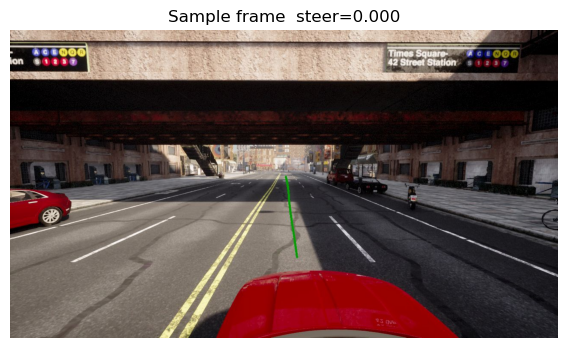

In [5]:
cam_id = int(topics_df.loc[topics_df["name"].str.contains("camera"), "id"].iloc[0])

cur = con.execute(
    "SELECT timestamp, data FROM messages "
    "WHERE topic_id = ? AND rowid BETWEEN 1 AND ?",
    (cam_id, MAX_ROWID)
)

SUBSAMPLE             = 3   # every 3rd frame → ~16k frames
MAX_TIMESTAMP_DIFF_NS = 50_000_000  # 50 ms
JPEG_MAGIC            = bytes([0xFF, 0xD8, 0xFF])

X_list, frame_steers = [], []
sample_img = None
skipped = 0
i = 0

for ts, data in cur:
    i += 1
    if i % SUBSAMPLE != 0:
        continue

    jpeg_start = data.find(JPEG_MAGIC)
    if jpeg_start < 0:
        continue

    img = cv2.imdecode(np.frombuffer(data[jpeg_start:], dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        continue

    idx = int(np.clip(np.searchsorted(ctrl_timestamps, ts), 0, len(ctrl_timestamps) - 1))
    if idx > 0 and abs(ctrl_timestamps[idx-1] - ts) < abs(ctrl_timestamps[idx] - ts):
        idx -= 1
    if abs(ctrl_timestamps[idx] - ts) > MAX_TIMESTAMP_DIFF_NS:
        continue

    feat = extract_features(img)
    if feat is None:
        skipped += 1
        continue

    X_list.append(feat)
    frame_steers.append(ctrl_steering[idx])

    if sample_img is None:
        sample_img = img.copy()

    if len(X_list) % 1000 == 0:
        print(f"  {len(X_list)} frames processed...")

con.close()
print(f"\nProcessed: {len(X_list)} frames  |  skipped (no segment): {skipped}")
print(f"Steering range: [{min(frame_steers):.3f}, {max(frame_steers):.3f}]")

plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title(f"Sample frame  steer={frame_steers[0]:.3f}")
plt.axis("off")
plt.show()

## 5. Convert steering to class labels + save raw floats

Class distribution:
  LEFT      :  2072  (12.9%)  mean_steer=-0.200
  STRAIGHT  : 11410  (71.3%)  mean_steer=-0.001
  RIGHT     :  2527  (15.8%)  mean_steer=+0.172


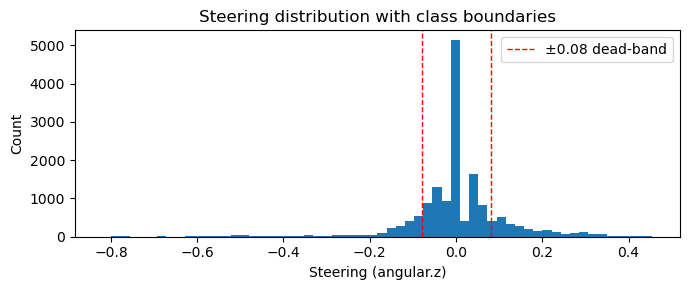

In [6]:
def steer_to_label(steer: float) -> int:
    if steer < -DEAD_BAND:
        return 0  # LEFT
    elif steer > DEAD_BAND:
        return 2  # RIGHT
    return 1      # STRAIGHT

y_steering = np.clip(np.array(frame_steers, dtype=np.float32), -1.0, 1.0)
y_labels   = np.array([steer_to_label(s) for s in y_steering], dtype=np.int32)

print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_labels == i
    n    = mask.sum()
    mean_steer = y_steering[mask].mean() if n > 0 else 0.0
    print(f"  {name:10s}: {n:5d}  ({100*n/len(y_labels):.1f}%)  mean_steer={mean_steer:+.3f}")

plt.figure(figsize=(7, 3))
plt.hist(y_steering, bins=60)
plt.axvline(-DEAD_BAND, color="red", linestyle="--", linewidth=1, label=f"±{DEAD_BAND} dead-band")
plt.axvline( DEAD_BAND, color="red", linestyle="--", linewidth=1)
plt.xlabel("Steering (angular.z)")
plt.ylabel("Count")
plt.title("Steering distribution with class boundaries")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature extraction (Lab07b pipeline)

For each frame:
1. Resize to 320×180, convert to grayscale
2. Crop ROI = bottom 55% (road only)
3. Gaussian blur → Canny edges
4. Probabilistic Hough transform to find line segments
5. Pick the longest segment as the dominant line
6. Crop a 64×64 edge patch centred on that segment
7. Flatten → 4096-element float32 feature vector

Frames with no detectable segment are skipped.

## 7. Build feature matrix X and filter no-line frames

In [7]:
X = np.array(X_list, dtype=np.float32)

print(f"Final X: {X.shape}  (N × 4098: flattened edge patch + x_norm + angle_norm)")
print(f"y_labels: {y_labels.shape}")
print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (y_labels == i).sum()
    print(f"  {name:10s}: {n:5d}  ({100*n/len(y_labels):.1f}%)")

# Sanity check: mean x_norm per class should differ (LEFT < 0 < RIGHT)
print("\nMean x_norm per class (feature index -2):")
for i, name in enumerate(CLASS_NAMES):
    mask = y_labels == i
    print(f"  {name:10s}: {X[mask, -2].mean():+.3f}")

Final X: (16009, 4098)  (N × 4098: flattened edge patch + x_norm + angle_norm)
y_labels: (16009,)
Class distribution:
  LEFT      :  2072  (12.9%)
  STRAIGHT  : 11410  (71.3%)
  RIGHT     :  2527  (15.8%)

Mean x_norm per class (feature index -2):
  LEFT      : +0.041
  STRAIGHT  : +0.020
  RIGHT     : -0.012


## 8. Save to data/

In [8]:
np.save(str(DATA_DIR / "X_features.npy"), X)
np.save(str(DATA_DIR / "y_labels.npy"),   y_labels)
np.save(str(DATA_DIR / "y_steering.npy"), y_steering)

print("Saved:")
for f in sorted(DATA_DIR.glob("*.npy")):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")
print("\nDone. Run 02_train_svm.ipynb next.")

Saved:
  X_features.npy  (256269 KB)
  y_labels.npy  (62 KB)
  y_steering.npy  (62 KB)

Done. Run 02_train_svm.ipynb next.
